In [1]:
import numpy as np 
import pandas as pd

In [2]:
import torch
import torch.nn as nn

In [3]:
from torchvision.datasets import MNIST

dataset = MNIST(
    root='./data',
    train=True,
    download=True
)

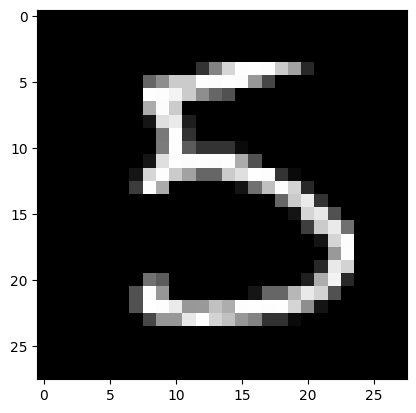

In [9]:
import matplotlib.pyplot as plt

image = test.data[15]

plt.imshow(image, cmap='gray')
plt.show()

In [4]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

tranform= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [5]:
train = MNIST(
    root='./data',
    train=True,
    download=True,
    transform=tranform
)
test = MNIST(
    root='./data',
    train=False,
    download=True,
    transform=tranform
)

In [6]:
train_loader=DataLoader(train,batch_size=32,shuffle=True)
test_loader=DataLoader(test,batch_size=32,shuffle=True)

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.convo_layers = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d( 32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d( 64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        
        self.fc_layer=nn.Sequential(
            nn.Linear(3*3*128,256),
            nn.ReLU(),

            nn.Linear(256,10)
        )
    def forward(self,x):
        x=self.convo_layers(x)
        x=x.view(x.size(0),-1)
        x=self.fc_layer(x)
        return x
    


In [8]:
import torch.optim as optim

model=CNN()

criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [9]:
device=torch.device('cuda')
model=model.to(device)

In [10]:
epochs=5

for epoch in range(epochs):
    epoch_training_loss=0.0

    for image, label in train_loader:
        
        image=image.to(device)
        label=label.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(image)

        outputs=outputs.to(device)
        
        loss = criteria(outputs, label)
        loss.backward()
        optimizer.step() # params update

        epoch_training_loss += loss.item()

    train_loss = epoch_training_loss / len(train_loader)

    print(f"epoch = {epoch+1}/{epochs}, loss = {train_loss}")

epoch = 1/5, loss = 0.12230025545799483
epoch = 2/5, loss = 0.04084834230421499
epoch = 3/5, loss = 0.02914210172385016
epoch = 4/5, loss = 0.023131985355637638
epoch = 5/5, loss = 0.01827905923653428


In [13]:
model.eval()
model.to('cpu')

correct=0
total=0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb) # [0.2, 0.5, 1.3, -0.5, ..] - 7 vals
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()
        total += yb.size(0) # actual samples in each batch

print("accuracy: ", correct/total * 100)

accuracy:  99.1


In [16]:
test.data[0].shape

torch.Size([28, 28])

torch.Size([1, 1, 28, 28])


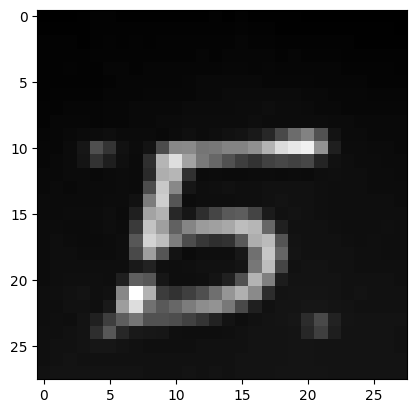

In [157]:
from PIL import Image, ImageOps
from torchvision import transforms
import matplotlib.pyplot as plt

# Load image
img = Image.open("WhatsApp Image 2026-05-30 at 9.07.37 PM.jpeg")

# Convert to grayscale
img = img.convert("L")

# Invert colors if your digit is black on white paper
img = ImageOps.invert(img)

# Resize to MNIST size
img = img.resize((28, 28))

img = tranform(img)

# Add batch dimension
img = img.unsqueeze(0)

print(img.shape)  # [1,1,28,28]

# Visualize final image
plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [146]:
prediction = model(img)

In [147]:
prediction
predicted=torch.max(prediction, 1)

In [148]:
outputs = model(img) # [0.2, 0.5, 1.3, -0.5, ..] - 7 vals
_, predicted = torch.max(outputs, 1)

In [149]:
predicted.item()

5